In [1]:
import torch
import torch.nn as nn
import random, os
from PIL import Image

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.datasets as datasets
import torch.nn.functional as F 
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

c:\Users\ChxraWish\anaconda3\envs\nvidiaGPU_ForVoiceGenTraining\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device = cuda


In [2]:
class SynchronizedTransform:
    def __init__(self, rotation_range=15, scale_range=(1, 1.2)):
        self.rotation_range = rotation_range
        self.scale_range = scale_range

    def __call__(self, past_img, present_img):
        angle = random.uniform(0, self.rotation_range)
        scale = random.uniform(self.scale_range[0], self.scale_range[1])

        transform = transforms.Compose([
            transforms.Resize((160, 160)),
            transforms.ToTensor(),
        ])

        return transform(past_img), transform(present_img)

In [3]:
class SimpleImageDataset(Dataset):
    def __init__(self, past_dir, present_dir, transform=None):
        self.past_dir = past_dir
        self.present_dir = present_dir
        self.transform = transform
        
        past_files = [f for f in os.listdir(past_dir) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        present_files = [f for f in os.listdir(present_dir) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        matching_files = []
        for past_file in past_files:
            if past_file in present_files:
                matching_files.append(past_file)
        
        self.pairs = []
        for filename in matching_files:
            past_path = os.path.join(past_dir, filename)
            present_path = os.path.join(present_dir, filename)
            
            if os.path.exists(past_path) and os.path.exists(present_path):
                self.pairs.append((past_path, present_path))
        
        print(f"Found {len(self.pairs)} matching image pairs")
        if len(self.pairs) == 0:
            raise ValueError("No matching image pairs found!")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        past_path, present_path = self.pairs[idx]
        
        past_img = Image.open(past_path).convert("RGB")
        present_img = Image.open(present_path).convert("RGB")
        
        if self.transform:
            if isinstance(self.transform, SynchronizedTransform):
                past_img, present_img = self.transform(past_img, present_img)
            else:
                  ใช้ seed เดียวกันสำหรับทั้งสองภาพ
                seed = random.randint(0, 2147483647)
                random.seed(seed)
                torch.manual_seed(seed)
                past_img = self.transform(past_img)
                random.seed(seed)
                torch.manual_seed(seed)
                present_img = self.transform(present_img)
        
        return past_img, present_img

sync_transform = SynchronizedTransform(rotation_range=15, scale_range=(0.8, 1.2))
dataset = SimpleImageDataset("Past_Augmented", "Present_Augmented", transform=sync_transform)
dataloader = DataLoader(dataset, batch_size=200, shuffle=False)

for past, present in dataloader:
    print(past.shape, present.shape)
    break


Found 760 matching image pairs
torch.Size([200, 3, 160, 160]) torch.Size([200, 3, 160, 160])


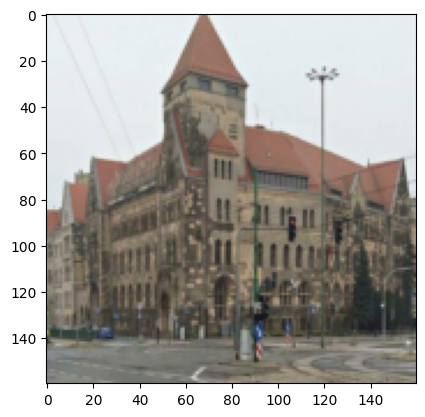

In [4]:
pastt, persentt = dataset[0]

plt.imshow(persentt.permute(1, 2, 0).cpu().numpy())
plt.show()

In [ ]:
class CNN_PastImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=2)

          self.upsample1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.convTrans1 = nn.Conv2d(256, 128, kernel_size=3, padding=1, stride=2)
          self.upsample2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.convTrans2 = nn.Conv2d(128, 64, kernel_size=3, padding=1, stride=2)
          self.upsample3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.convTrans3 = nn.Conv2d(64, 32, kernel_size=3, padding=1, stride=2)
          self.upsample4 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.convTrans4 = nn.Conv2d(32, 3, kernel_size=3, padding=1, stride=2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
          x = self.upsample1(x)
        x = F.relu(self.convTrans1(x))
          x = self.upsample2(x)
        x = F.relu(self.convTrans2(x))
          x = self.upsample3(x)
        x = F.relu(self.convTrans3(x))
          x = self.upsample4(x)
        x = torch.sigmoid(self.convTrans4(x))
        return x

model = CNN_PastImage().to(device)
  summary(model, )


In [6]:
criterion = nn.MSELoss()

In [7]:

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)


In [8]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=.995)

In [9]:
  
model.train()
  loss ต้องได้ 0.003
epochs = 200
save_path = 'model_checkpoint_3.pth'
for epoch in range(epochs):
    for past_imgs, present_imgs in dataloader:
        past_imgs = past_imgs.to(device)
        present_imgs = present_imgs.to(device)
        output = model(past_imgs)
        loss = criterion(output.to(device), present_imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

      แสดงผลสถานะการเทรนเพียงครั้งเดียวต่อ epoch
      print("alsdkfaiefa")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}, lr: {optimizer.param_groups[0]['lr']}")
    if (epoch + 1) % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': loss.item(),
        }, save_path)
        print("Model saved")

c:\Users\ChxraWish\anaconda3\envs\nvidiaGPU_ForVoiceGenTraining\lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([200, 3, 160, 160])) that is different to the input size (torch.Size([200, 3, 10, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (10) must match the size of tensor b (160) at non-singleton dimension 3

torch.Size([200, 3, 160, 160])


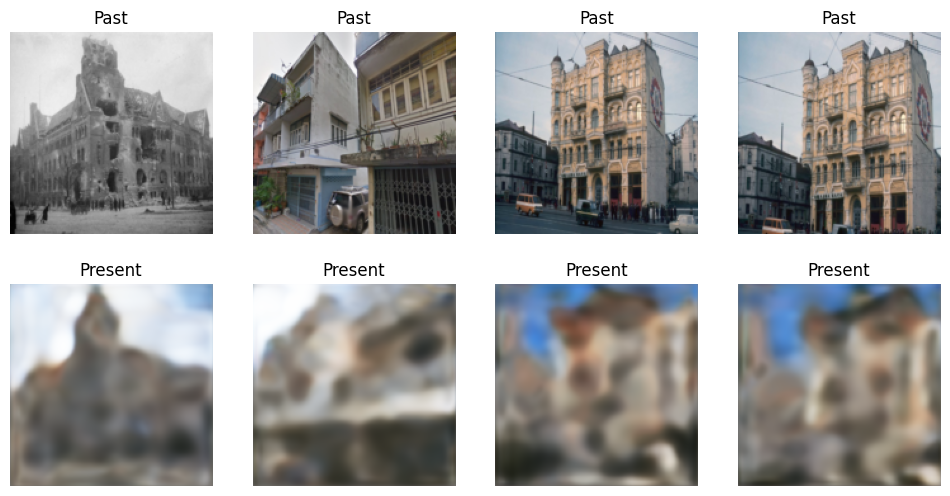

In [ ]:
imags, _ = next(iter(dataloader))

model.eval()
with torch.no_grad():
    output = model(imags.to(device))
print(output.shape)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    input_image = imags[i].permute(1, 2, 0).cpu().numpy()
    output_image = output[i].permute(1, 2, 0).cpu().numpy()

    input_image = np.clip(input_image, 0, 1)
    output_image = np.clip(output_image, 0, 1)
    axes[0, i].imshow(input_image)
    axes[0, i].set_title('Past')
    axes[0, i].axis('off')

    axes[1, i].imshow(output_image)
    axes[1, i].set_title('Present')
    axes[1, i].axis('off')

In [ ]:
  torch.cuda.empty_cache()

In [ ]:
  Load model checkpoint to resume training
checkpoint = torch.load('model_checkpoint_3.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Resuming training from epoch {start_epoch+1} with loss {loss}")

Resuming training from epoch 200 with loss 0.01066476758569479
